# 03 - RNN and CNN

BiLSTM / BiGRU, TextCNN and CNN-BiLSTM on the shared split. Same metrics and experiment log as the baselines and transformers, so everything in `results/experiments.csv` is comparable.

What we took from the EDA (01_eda):
- 99% of tweets are 33 tokens or fewer, so max_len = 40 cuts nothing.
- half the vocab appears once, so min_freq = 2 with an `<unk>` token, and pretrained embeddings to cover the rest.
- only 10% negative, so macro-F1 is the main metric and class weights are worth trying.
- all 239 agreement = 0.333 tweets are negative, so the same agreement experiments as the baselines.

Every run is saved in `results/runs/<exp_id>.json` (settings, scores, per-epoch history, predictions). With `RETRAIN = False` the notebook reloads those files, so it runs top to bottom in a minute. Set `RETRAIN = True` to train everything again (use a GPU runtime; on a laptop cpu one bilstm run takes 10-20 min).

In [1]:
import os, sys

# on colab clone the repo, locally just move up from notebooks/
if "google.colab" in sys.modules:
    if not os.path.exists("/content/NLP_and_Language_technologies-Group-9"):
        !git clone https://github.com/Samkwizera/NLP_and_Language_technologies-Group-9.git /content/NLP_and_Language_technologies-Group-9
    %cd /content/NLP_and_Language_technologies-Group-9
    !pip install -q -r requirements.txt
    # csvs aren't in git, so copy them from drive (MyDrive/nlp_data/)
    from google.colab import drive
    drive.mount("/content/drive")
    import glob, shutil
    # zindi downloads come as "train (1).csv" etc, the code expects Train.csv / Test.csv
    for f in glob.glob("/content/drive/MyDrive/nlp_data/*.csv"):
        name = os.path.basename(f).lower()
        if name.startswith("train"):
            shutil.copy(f, "data/Train.csv")
        elif name.startswith("test"):
            shutil.copy(f, "data/Test.csv")
    if not os.path.exists("data/Train.csv"):
        raise FileNotFoundError("put the train/test csvs in MyDrive/nlp_data/")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
os.listdir("data")

['embeddings', 'README.md', 'Test.csv', 'Train.csv']

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src import config
from src.dataset import Vocab, coverage_report
from src.embeddings import embedding_coverage, load_vectors, lookup
from src.evaluate import compute_metrics, export_errors, plot_confusion_matrix, plot_training_history
from src.models.rnn_cnn import learning_curve, model_name, run_or_load
from src.split import load_split
from src.utils import add_takeaway, ensure_dirs, set_seed

set_seed()
ensure_dirs()
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 70)
FIG = config.FIGURES_DIR

RETRAIN = False
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

train, val, test = load_split()
print(len(train), len(val), len(test))

device: cpu
6995 1502 1503


In [3]:
RUNS = {}

def run(exp_id, **kwargs):
    RUNS[exp_id] = run_or_load(exp_id, train, val, retrain=RETRAIN, **kwargs)
    return RUNS[exp_id]


def table(ids):
    rows = []
    for i in ids:
        r, s = RUNS[i], RUNS[i].get("settings", {})
        m = r["metrics"]
        rows.append({"exp_id": i, "change": r.get("change", ""), "model": model_name(s.get("model", "bilstm"), s.get("embeddings", "random"), s.get("freeze", False)),
                     "macro_f1": m["macro_f1"], "accuracy": m["accuracy"], "f1_neg": m["f1_negative"],
                     "f1_neu": m["f1_neutral"], "f1_pos": m["f1_positive"], "epochs": m["epochs"]})
    return pd.DataFrame(rows).set_index("exp_id")

## 1. Turning tweets into sequences

Tokens come from the team's `pp.tokenize` (lowercased, `<user>`/`<url>` kept, hashtags kept whole, emojis and punctuation kept). The vocab is built on the train split only, so val and test words the model never saw become `<unk>`. Every tweet is padded / cut to 40 ids and we keep the real length so the lstm can skip the padding (packed sequences).

In [4]:
rows = {}
for split_h in [False, True]:
    vocab = Vocab.build(train["safe_text"], split_hashtags=split_h)
    rows["hashtags split" if split_h else "hashtags whole"] = coverage_report(vocab, val, split_h)
pd.DataFrame(rows)

,hashtags whole,hashtags split
vocab_size,5319.0000,5263.0000
token_coverage,0.9254,0.9313
type_coverage,0.5904,0.6038
truncated_tweets,0.0000,0.0000


- The train vocab (min_freq 2) covers about 92.5% of the val tokens but only 59% of the distinct val words. The frequent words are known, the long tail is not: about 4 in 10 word types in val never appeared twice in train.
- A randomly initialised embedding can't learn anything about those words from 7k tweets, which is the main argument for pretrained vectors.
- max_len 40 truncates nothing.

### Pretrained embeddings: how much of our text do they cover?
- **GloVe Twitter 200d** (Pennington et al., 2014): trained on 2B tweets with the same `<user>`, `<url>` and `<hashtag>` placeholders our data uses.
- **fastText crawl 300d** (Mikolov et al., 2018): 2M words from 600B tokens of web text. Bigger vocab, but not twitter and no placeholders.

With pretrained vectors we also keep words seen only once in train if they have a vector, since the model doesn't have to learn them from one example (R8 tests whether this helps).

The embedding files are big (1.4 GB each), so the coverage numbers are saved to `results/embedding_coverage.csv` and only recomputed when `RETRAIN = True`.

In [5]:
cov_path = config.RESULTS_DIR / "embedding_coverage.csv"
if RETRAIN or not cov_path.exists():
    rows = []
    for name in ["glove", "fasttext"]:
        vectors = load_vectors(name)
        base = Vocab.build(train["safe_text"])
        keep = Vocab.build(train["safe_text"], keep=lambda w: lookup(w, vectors) is not None)
        missing = [w for w in ["<user>", "<url>", "<hashtag>"] if w not in vectors]
        rows.append({"embedding": name, "vocab_min_freq_2": len(base), "vocab_with_rare_kept": len(keep),
                     **embedding_coverage(base, vectors, val), "missing_placeholders": " ".join(missing) or "-"})
    pd.DataFrame(rows).to_csv(cov_path, index=False)
pd.read_csv(cov_path).set_index("embedding")

,vocab_min_freq_2,vocab_with_rare_kept,vocab_with_vector,tokens_with_vector,missing_placeholders
embedding,,,,,
glove,5319,10287,0.8920,0.9481,-
fasttext,5319,10507,0.9408,0.9239,<user> <url> <hashtag>


- fastText has a vector for more of our vocab words, but GloVe covers more of the running text (about 95% vs 92% of val tokens). That is mostly because `<user>` and `<url>` make up 5.2% of the val tokens and only GloVe has vectors for them.
- Keeping rare words that have a vector roughly doubles the vocab (5.3k -> 10k).

## 2. Setup for the experiments

Same for every run unless the table says otherwise:
- BiLSTM: 1 layer, 128 hidden units each way, max pooling over the time steps, dropout 0.5 on the embeddings and before the output layer.
- Adam, lr 1e-3, batch 64, gradient clipping at 1.0.
- Up to 30 epochs with early stopping on **val macro-F1** (patience 5). We stop on macro-F1 rather than val loss because that's the number we report, and the two disagree here (see the learning curves below).
- Seed 42. Val is only 1,502 tweets, so single-run differences under about 0.01-0.02 can be noise. The final configs are rerun with 3 seeds in section 7.

Samuel's best TF-IDF result on val is 0.685 (logreg, A2). twitter-roberta is 0.741 (T1).

## 3. Embeddings (R1-R5, C1-C2)

Question: does starting from pretrained vectors help with only 7k training tweets, and does it matter which ones?

In [6]:
run("R1", model="bilstm", embeddings="random",
    change="bilstm, random embeddings", reason="starting point for the neural models")
run("R2", model="bilstm", embeddings="glove", freeze=True,
    change="glove twitter 200d, frozen", reason="only 7k training tweets and 41% of val word types are unseen, pretrained vectors should help")
run("R3", model="bilstm", embeddings="glove", freeze=False,
    change="glove twitter 200d, fine-tuned", reason="does adapting the vectors to vaccine stance help or overfit")
run("R4", model="bilstm", embeddings="fasttext", freeze=True,
    change="fasttext crawl 300d, frozen", reason="compare a big general web vocab with glove twitter")
run("R5", model="bilstm", embeddings="fasttext", freeze=False,
    change="fasttext crawl 300d, fine-tuned", reason="does adapting the vectors help or overfit on 7k tweets")
run("C1", model="cnn", embeddings="random",
    change="textcnn (3/4/5 x 100 filters), random embeddings", reason="cnn picks up local n-gram cues, compare with the bilstm reading the whole sequence")
run("C2", model="cnn", embeddings="glove",
    change="textcnn + glove twitter, fine-tuned", reason="same embedding step as the bilstm (R1 -> R3)")
table(["R1", "R2", "R3", "R4", "R5", "C1", "C2"])

,change,model,macro_f1,accuracy,f1_neg,f1_neu,f1_pos,epochs
exp_id,,,,,,,,
R1,,bilstm+random-emb,0.6287,0.7237,0.3655,0.7933,0.7273,20
R2,"glove twitter 200d, frozen",bilstm+glove-frozen,0.6407,0.7483,0.3557,0.8194,0.7470,15
R3,"glove twitter 200d, fine-tuned",bilstm+glove-tuned,0.6538,0.7324,0.4195,0.8088,0.7331,10
R4,,bilstm+fasttext-frozen,0.6499,0.7463,0.3902,0.8265,0.7330,12
R5,,bilstm+fasttext-tuned,0.6454,0.7204,0.4202,0.7994,0.7165,10
C1,"textcnn (3/4/5 x 100 filters), random embeddings",cnn+random-emb,0.6268,0.7257,0.3623,0.7968,0.7214,30
C2,"textcnn + glove twitter, fine-tuned",cnn+glove-tuned,0.6509,0.7337,0.4217,0.8073,0.7238,11


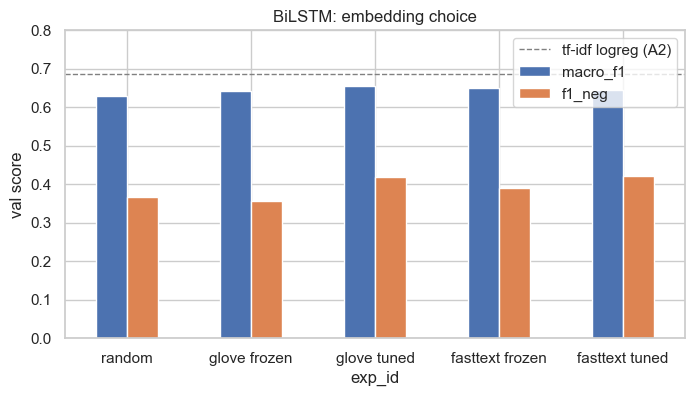

In [7]:
emb = table(["R1", "R2", "R3", "R4", "R5"])
ax = emb[["macro_f1", "f1_neg"]].rename(index=dict(zip(emb.index, ["random", "glove frozen", "glove tuned", "fasttext frozen", "fasttext tuned"]))).plot.bar(rot=0, figsize=(8, 4))
ax.axhline(0.685, color="grey", ls="--", lw=1, label="tf-idf logreg (A2)")
ax.set_ylim(0, 0.8)
ax.set_ylabel("val score")
ax.set_title("BiLSTM: embedding choice")
ax.legend()
plt.savefig(FIG / "rnn_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

- Pretrained vectors help both architectures by about +0.02 macro-F1 (R1 0.629 -> R3 0.654, C1 0.627 -> C2 0.651).
- Between the four pretrained variants the spread is about 0.013, which is inside the noise on this val set, so this doesn't prove one embedding is better. We go on with **GloVe fine-tuned** because it scored highest and because it's the only one with vectors for `<user>` and `<url>`.
- Fine-tuning vs freezing is not consistent (it helps GloVe, slightly hurts fastText). With 7k tweets the extra freedom can go either way.
- All of these are still below the TF-IDF baseline (0.685), and the gap is almost all in the negative class (F1 0.36-0.42 vs 0.48).

### Learning curves

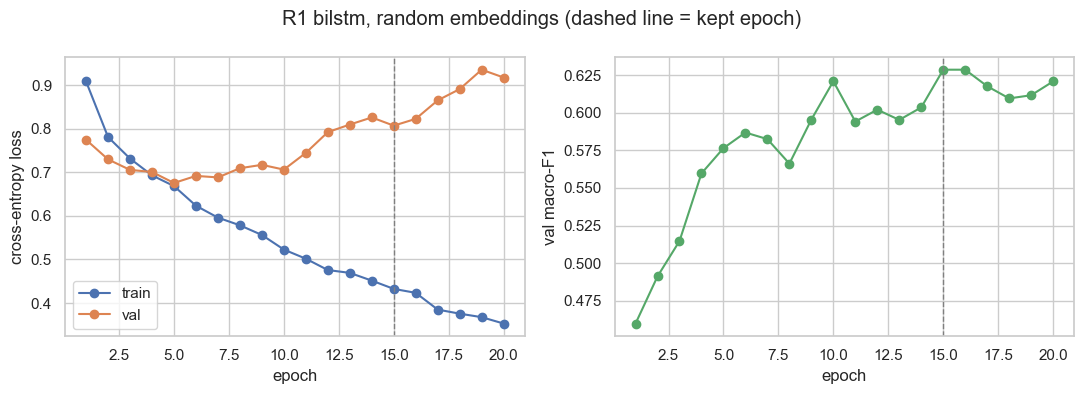

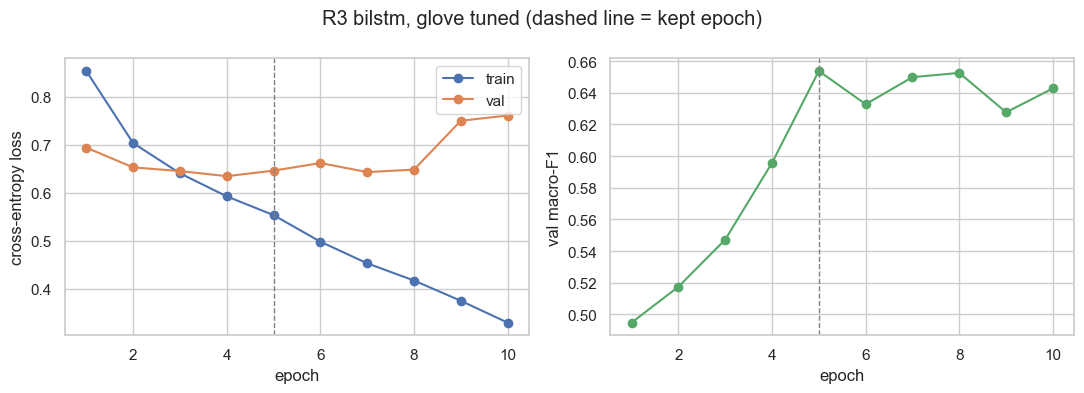

In [8]:
plot_training_history(RUNS["R1"]["history"], "R1 bilstm, random embeddings", "rnn_history_R1")
plot_training_history(RUNS["R3"]["history"], "R3 bilstm, glove tuned", "rnn_history_R3")

- Val loss is lowest after 4-5 epochs and then rises while train loss keeps falling, so the models start overfitting early. Random embeddings take longer (val loss is best at epoch 5, macro-F1 at epoch 15) because the model first has to learn word meanings from scratch.
- Macro-F1 keeps improving for a while after the val loss minimum. The model becomes more confident (which the loss punishes when it's wrong) but also starts predicting the rare negative class, which is what macro-F1 rewards. This is why we stop on macro-F1 and not on loss.

## 4. Vocab and hashtags (R6-R8)

Starting from R3, one change at a time.

In [9]:
run("R6", model="bilstm", embeddings="glove", class_weight="balanced",
    change="R3 + balanced class weights", reason="negative F1 is still only 0.42 and macro-F1 only rises late as the model starts predicting negatives. class weights gave the baselines their biggest gain (B3)")
run("R7", model="bilstm", embeddings="glove", split_hashtags=True,
    change="R3 + hashtags split into <hashtag> word", reason="matches how glove twitter was trained, and hashtag words like vaccineswork get a vector")
run("R8", model="bilstm", embeddings="glove", keep_rare=False,
    change="R3 without keeping rare words that have a glove vector", reason="ablation: does keeping the ~5k words seen once in train (but known to glove) help")
table(["R3", "R6", "R7", "R8"])

,change,model,macro_f1,accuracy,f1_neg,f1_neu,f1_pos,epochs
exp_id,,,,,,,,
R3,"glove twitter 200d, fine-tuned",bilstm+glove-tuned,0.6538,0.7324,0.4195,0.8088,0.7331,10
R6,R3 + balanced class weights,bilstm+glove-tuned,0.6502,0.7270,0.4268,0.7873,0.7365,14
R7,R3 + hashtags split into <hashtag> word,bilstm+glove-tuned,0.6696,0.7477,0.4497,0.8089,0.7502,13
R8,R3 without keeping rare words that have a glove vector,bilstm+glove-tuned,0.6281,0.7364,0.3413,0.8017,0.7414,15


- **Splitting hashtags (R7) is the best change: 0.654 -> 0.670**, and negative F1 goes from 0.42 to 0.45. Words inside hashtags (#vaccineswork, #cdcwhistleblower) now get a GloVe vector, and `<hashtag>` itself is a known GloVe token.
- **Keeping rare words that have a vector matters (R8): removing them drops the score to 0.628.** Those ~5k words appear only once in train, but GloVe already knows what they mean.
- **Class weights do nothing for the bilstm (R6: 0.650 vs 0.654)**, even though they were the biggest gain for the baselines (B3). One likely reason: 23% of the negatives are the agreement = 0.333 tweets that were defaulted to negative, so weighting the negative class ~3x also gives ~3x weight to its noisiest labels. Early stopping on macro-F1 also already picks the epoch where the model predicts negatives most usefully, which does part of what class weights do.

## 5. Cell type and agreement (R9-R12)

From here R7 is the base.

In [10]:
run("R9", model="bigru", embeddings="glove", split_hashtags=True,
    change="bigru instead of bilstm (R7 settings)", reason="a gru has about 25% fewer recurrent weights, which may suit 7k tweets better")
B = dict(model="bilstm", embeddings="glove", split_hashtags=True)
run("R10", **B, agreement="high",
    change="R7, trained only on agreement = 1", reason="cleaner labels, but loses ~63% of negatives. best setting for the logreg baseline (A2)")
run("R11", **B, agreement="drop_333",
    change="R7, dropped agreement = 0.333", reason="those tweets had no majority and were all defaulted to negative")
run("R12", **B, agreement="weighted",
    change="R7, loss weighted by agreement", reason="keep all data but trust uncertain labels less")
table(["R7", "R9", "R10", "R11", "R12"])

,change,model,macro_f1,accuracy,f1_neg,f1_neu,f1_pos,epochs
exp_id,,,,,,,,
R7,R3 + hashtags split into <hashtag> word,bilstm+glove-tuned,0.6696,0.7477,0.4497,0.8089,0.7502,13
R9,bigru instead of bilstm (R7 settings),bigru+glove-tuned,0.6523,0.7450,0.3972,0.8122,0.7475,10
R10,"R7, trained only on agreement = 1",bilstm+glove-tuned,0.6512,0.7383,0.4039,0.8166,0.7330,20
R11,"R7, dropped agreement = 0.333",bilstm+glove-tuned,0.6475,0.7410,0.3984,0.8025,0.7416,14
R12,"R7, loss weighted by agreement",bilstm+glove-tuned,0.6616,0.7523,0.4138,0.8258,0.7452,15


- BiGRU (0.652) is below BiLSTM (0.670) with the same settings, mostly on the negative class (0.40 vs 0.45).
- **None of the agreement settings beats training on everything.** Agreement = 1 only (R10) loses 0.018, the opposite of the logreg baseline, where it was the best setting (A2). A plausible explanation: the bilstm has many more parameters than a linear model, so going from 1,038 to 382 negative examples hurts it more than the cleaner labels help. Weighting the loss by agreement (R12, 0.662) is the least harmful, which fits that reading: it keeps all examples and only trusts the uncertain ones less.

## 6. Small tuning round (R13-R15) and the CNN models (C3, C4, CB1)

In [11]:
run("R13", **B, pooling="last",
    change="R7 with the final hidden states instead of max pooling", reason="the classic bilstm setup, checks whether max pooling over all steps is actually better")
run("R14", **B, pooling="mean",
    change="R7 with mean pooling", reason="mean pooling uses every step, max pooling only the strongest one per unit")
run("R15", **B, hidden=64,
    change="R7 with 64 hidden units instead of 128", reason="val loss rises after ~5 epochs, a smaller model might overfit less")
run("C3", model="cnn", embeddings="glove", split_hashtags=True,
    change="C2 + hashtags split into <hashtag> word", reason="hashtag splitting was the best bilstm change (R3 -> R7), check it carries over to the cnn")
run("C4", model="cnn", embeddings="glove", split_hashtags=True, kernel_sizes=(2, 3, 4),
    change="C3 with 2/3/4-word filters instead of 3/4/5", reason="tweets are ~20 tokens and the stance cues are short phrases (vaccines work, cdc whistleblower)")
run("CB1", model="cnn-bilstm", embeddings="glove",
    change="cnn-bilstm + glove twitter, fine-tuned", reason="conv finds local phrases, the bilstm reads them in order. does combining both beat either alone (R3, C2)")
table(["R7", "R13", "R14", "R15", "C2", "C3", "C4", "CB1"])

,change,model,macro_f1,accuracy,f1_neg,f1_neu,f1_pos,epochs
exp_id,,,,,,,,
R7,R3 + hashtags split into <hashtag> word,bilstm+glove-tuned,0.6696,0.7477,0.4497,0.8089,0.7502,13
R13,R7 with the final hidden states instead of max pooling,bilstm+glove-tuned,0.6591,0.7523,0.4106,0.8152,0.7514,13
R14,R7 with mean pooling,bilstm+glove-tuned,0.6559,0.7423,0.4169,0.8222,0.7287,11
R15,R7 with 64 hidden units instead of 128,bilstm+glove-tuned,0.6577,0.7563,0.3968,0.8176,0.7585,13
C2,"textcnn + glove twitter, fine-tuned",cnn+glove-tuned,0.6509,0.7337,0.4217,0.8073,0.7238,11
C3,C2 + hashtags split into <hashtag> word,cnn+glove-tuned,0.6571,0.7483,0.4138,0.8072,0.7504,12
C4,C3 with 2/3/4-word filters instead of 3/4/5,cnn+glove-tuned,0.6615,0.7463,0.4328,0.8053,0.7464,15
CB1,"cnn-bilstm + glove twitter, fine-tuned",cnn-bilstm+glove-tuned,0.6400,0.7130,0.4078,0.8144,0.6979,11


- Max pooling (R7) stays the best way to summarise the bilstm outputs. The last hidden state (0.659) and mean pooling (0.656) are both lower, and so is a smaller model (0.658). These differences are all inside the noise band, so the honest conclusion is "no tuning change helped", not "max pooling is proven better".
- The CNN follows the same pattern as the bilstm: glove +0.024 (C1 -> C2), hashtag splitting +0.006 (C3), and shorter 2/3/4 filters give the best CNN at 0.662 (C4), close to the best bilstm.
- **CNN-BiLSTM (0.640) is worse than either part alone** (same settings: bilstm R3 0.654, cnn C2 0.651). Stacking the two adds parameters without adding information on 20-token tweets.

### Are these differences real?

Val has 1,502 tweets, so we check the main steps with a paired bootstrap (resample the val tweets 1,000 times and recompute both models' macro-F1 on the same sample) and McNemar's test (only tweets where exactly one of the two models is right count).

In [12]:
from src.compare import mcnemar, paired_bootstrap, preds_from_errors

y = val["label"].values
P = {k: RUNS[k]["preds"] for k in RUNS}
P["logreg (A2)"] = preds_from_errors(val, "baseline_logreg")
P["twitter-roberta (T1)"] = preds_from_errors(val, "T1")

pairs = [("R3", "R1"), ("R7", "R3"), ("R3", "R8"), ("R7", "R9"), ("R7", "R10"), ("R7", "C4"),
         ("logreg (A2)", "R7"), ("twitter-roberta (T1)", "R7")]
rows = []
for a, b in pairs:
    (lo, hi), p_b = paired_bootstrap(y, P[a], P[b], n=1000)
    only_a, only_b, p = mcnemar(y, P[a], P[b])
    rows.append({"A": a, "B": b, "diff_ci_low": round(lo, 3), "diff_ci_high": round(hi, 3),
                 "P(B >= A)": round(p_b, 3), "only A right": only_a, "only B right": only_b, "mcnemar p": round(p, 3)})
sig = pd.DataFrame(rows)
sig.to_csv(config.RESULTS_DIR / "rnn_significance_val.csv", index=False)
sig

,A,B,diff_ci_low,diff_ci_high,P(B >= A),only A right,only B right,mcnemar p
0,R3,R1,-0.005,0.056,0.050,126,113,0.438
1,R7,R3,-0.006,0.039,0.091,93,70,0.085
2,R3,R8,-0.003,0.054,0.044,101,107,0.729
3,R7,R9,-0.002,0.038,0.038,69,65,0.796
4,R7,R10,-0.005,0.046,0.073,103,89,0.348
5,R7,C4,-0.016,0.033,0.256,84,82,0.938
6,logreg (A2),R7,-0.014,0.045,0.153,121,100,0.178
7,twitter-roberta (T1),R7,0.038,0.099,0.000,175,92,0.000


- The only clear difference is twitter-roberta over the best bilstm: the 95% interval of the gap is about +0.04 to +0.10 and McNemar p < 0.001.
- Each single step in the bilstm ladder (pretrained embeddings, hashtag splitting, keeping rare words, lstm over gru) points the same way but on its own is borderline (the "worse" model comes out ahead in roughly 4-9% of resamples). The direction is consistent across steps and across the CNN, which is why we trust them together more than any one alone.
- **The best bilstm and the TF-IDF logreg can't be separated** (interval includes 0, p = 0.18). On 7k tweets, sequence models with pretrained word vectors only match a well-tuned bag of n-grams.

## 7. Seeds

Neural nets start from random weights and see the batches in a random order, so the same config can land in a different place. We rerun the best bilstm (R7), the best cnn (C4) and the random-embedding starting point (R1) with seeds 1 and 7 on top of 42. These extra runs are not logged one by one; each config gets one summary row in `experiments.csv`.

In [13]:
R7_CFG = dict(model="bilstm", embeddings="glove", split_hashtags=True)
C4_CFG = dict(model="cnn", embeddings="glove", split_hashtags=True, kernel_sizes=(2, 3, 4))
R1_CFG = dict(model="bilstm", embeddings="random")
SEEDS = {"_s1": 1, "_s2": 7}

for base, cfg in [("R7", R7_CFG), ("C4", C4_CFG), ("R1", R1_CFG)]:
    for suffix, seed in SEEDS.items():
        run(base + suffix, **cfg, seed=seed, log=False)

def seed_summary(base):
    scores = pd.DataFrame([RUNS[k]["metrics"] for k in [base, base + "_s1", base + "_s2"]])
    cols = ["macro_f1", "accuracy", "rmse", "f1_negative", "f1_neutral", "f1_positive"]
    return scores[cols].agg(["mean", "std"]).round(4)

seeds = pd.concat({b: seed_summary(b) for b in ["R1", "R7", "C4"]})
seeds

macro_f1  accuracy    rmse  f1_negative  f1_neutral  f1_positive
R1 mean    0.6227    0.7226  0.7277       0.3477      0.7980       0.7224
   std     0.0090    0.0077  0.0175       0.0386      0.0079       0.0076
R7 mean    0.6584    0.7430  0.6923       0.4258      0.8062       0.7432
   std     0.0109    0.0047  0.0105       0.0268      0.0042       0.0082
C4 mean    0.6600    0.7481  0.6704       0.4248      0.8078       0.7474
   std     0.0123    0.0017  0.0166       0.0369      0.0032       0.0021

- Over 3 seeds the bilstm (R7 config) averages **0.658 ± 0.011** and the textcnn (C4 config) **0.660 ± 0.012**. The two architectures are tied; the seed-42 numbers (0.670 and 0.662) were on the lucky side for the bilstm.
- Random embeddings average 0.623 ± 0.009, so the GloVe + vocab + hashtag setup is worth about **+0.035**, three times the seed spread. That's the one gain in this notebook that clearly holds up.
- The seed spread (about 0.01, and 0.03-0.04 for negative F1) is as large as most single changes in sections 4-6. This is why those steps are reported as consistent directions rather than proven improvements.

In [14]:
from src.utils import log_experiment

notes = {"R1": "bilstm + random embeddings", "R7": "bilstm + glove tuned + split hashtags", "C4": "textcnn 2/3/4 + glove tuned + split hashtags"}
for base, name in [("R1", "bilstm+random-emb"), ("R7", "bilstm+glove-tuned"), ("C4", "cnn+glove-tuned")]:
    s = seed_summary(base)
    log_experiment(exp_id=f"{base}x3", member="Divine", model=name,
                   change=f"{notes[base]}, mean of 3 seeds (42, 1, 7), std {s.loc['std', 'macro_f1']:.3f}",
                   reason="val is only 1.5k tweets, check the result isn't one lucky seed",
                   macro_f1=s.loc["mean", "macro_f1"], accuracy=s.loc["mean", "accuracy"], rmse=s.loc["mean", "rmse"])

## 8. Final test runs

The configs were picked on val only. Now R7 and C4 are trained again with the same settings and scored once on the test split (early stopping still watches val). We also run the two other seeds on test so the test number comes with a spread.

In [15]:
def run_test(exp_id, **kwargs):
    RUNS[exp_id] = run_or_load(exp_id, train, val, test, retrain=RETRAIN, **kwargs)
    return RUNS[exp_id]

run_test("RT1", **R7_CFG, change="final bilstm on test (R7 config)", reason="final evaluation of the best val config")
run_test("CT1", **C4_CFG, change="final textcnn on test (C4 config)", reason="final evaluation of the best val config")
for base, cfg in [("RT1", R7_CFG), ("CT1", C4_CFG)]:
    for suffix, seed in SEEDS.items():
        run_test(base + suffix, **cfg, seed=seed, log=False)

pd.concat({b: seed_summary(b) for b in ["RT1", "CT1"]})

macro_f1  accuracy    rmse  f1_negative  f1_neutral  f1_positive
RT1 mean    0.6625    0.7359  0.6862       0.4583      0.7917       0.7375
    std     0.0138    0.0024  0.0123       0.0436      0.0038       0.0014
CT1 mean    0.6516    0.7334  0.6923       0.4281      0.7966       0.7299
    std     0.0116    0.0057  0.0169       0.0244      0.0055       0.0107

- Test macro-F1: **bilstm 0.662 ± 0.014, textcnn 0.652 ± 0.012** (3 seeds). Both are close to their val averages (0.658 and 0.660), so picking configs on val didn't overfit it.
- Both are below the TF-IDF baselines on test (svm 0.684, logreg 0.680) by about 0.02-0.03. Negative F1 is the gap again: 0.46 for the bilstm vs 0.52 for the svm.

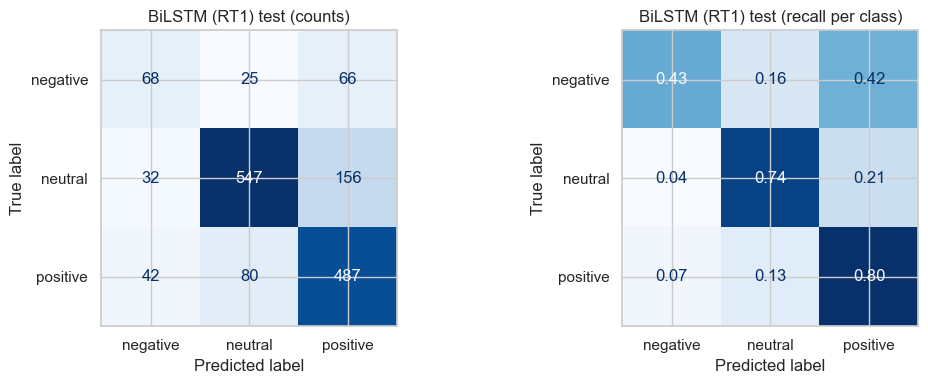

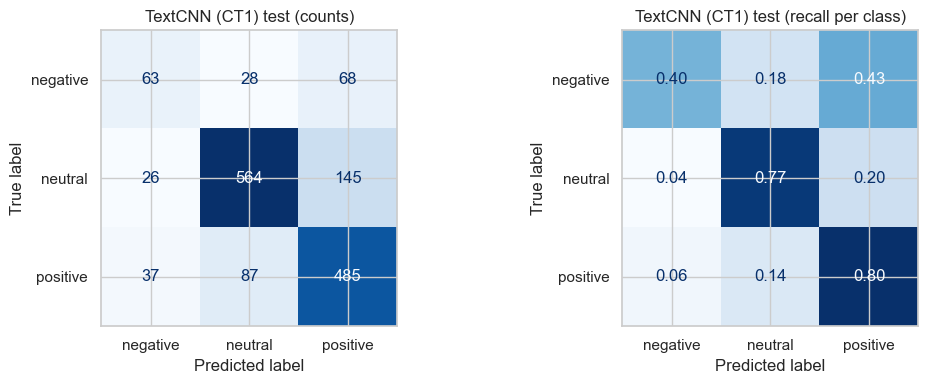

In [16]:
y_test = test["label"].values
plot_confusion_matrix(y_test, RUNS["RT1"]["preds"], "BiLSTM (RT1) test", "rnn_bilstm_test_cm")
plot_confusion_matrix(y_test, RUNS["CT1"]["preds"], "TextCNN (CT1) test", "rnn_cnn_test_cm")

- Negative is where both models fail: only about 41% of negative test tweets are caught (68/159 for the bilstm), and almost as many (42%) are predicted as **positive**. These tweets share the vocabulary of pro-vaccine tweets (vaccine, kids, measles, cdc) and the stance is in the framing, which a word-level model reads at face value. The baselines and transformers make the same mistake (see their error files).
- The largest error by count is neutral -> positive (156 tweets, about 21% of neutral). Many neutral tweets are news about vaccination campaigns, which use the same words as positive tweets.

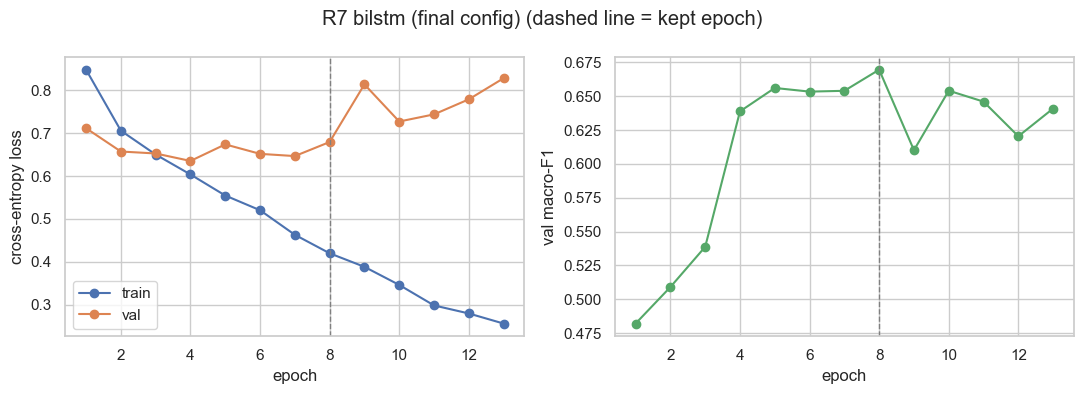

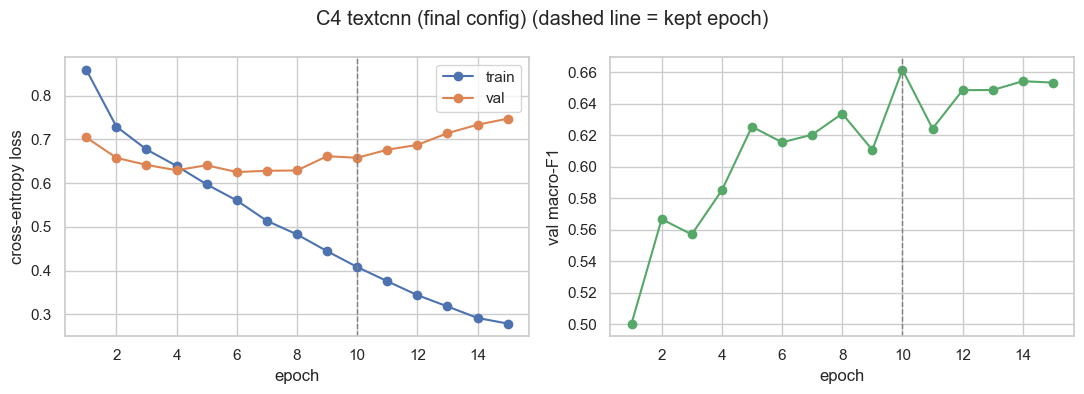

In [17]:
plot_training_history(RUNS["R7"]["history"], "R7 bilstm (final config)", "rnn_history_R7")
plot_training_history(RUNS["C4"]["history"], "C4 textcnn (final config)", "rnn_history_C4")

### Errors for the error analysis

Same format as the baseline and transformer error files (val misclassifications, most confident first), so all models can be compared tweet by tweet.

In [18]:
for exp_id in ["R7", "C4"]:
    err = export_errors(val, RUNS[exp_id]["preds"], RUNS[exp_id]["confidence"], exp_id)
    print(exp_id, len(err), "val errors")
pd.crosstab(err["true"], err["predicted"])

R7 379 val errors
C4 381 val errors


predicted,-1,0,1
true,,,
-1,0,23,73
0,25,0,142
1,31,87,0


## 9. How much data does the bilstm need?

Same subsets as the baseline learning curve (10/25/50/75/100% of train, sampled within each label). Training five bilstms takes about an hour on a cpu, so the scores are saved to `results/learning_curve_*.csv` and only recomputed with `RETRAIN = True`.

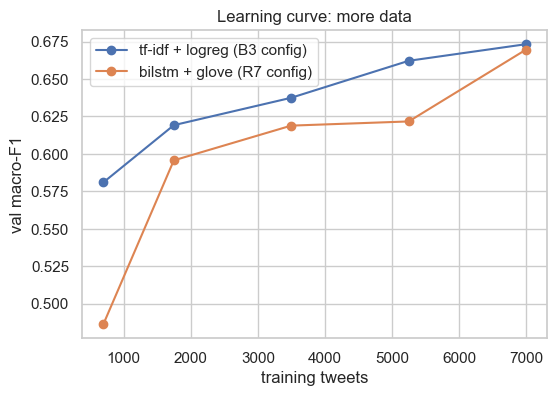

,model,fraction,train_tweets,val_macro_f1
0,logreg,0.10,699,0.5810
1,logreg,0.25,1748,0.6192
2,logreg,0.50,3496,0.6375
3,logreg,0.75,5247,0.6622
4,logreg,1.00,6995,0.6733
0,bilstm,0.10,699,0.4863
1,bilstm,0.25,1748,0.5957
2,bilstm,0.50,3496,0.6189
3,bilstm,0.75,5247,0.6217
4,bilstm,1.00,6995,0.6697


In [19]:
from src.models import baselines
from src.models.rnn_cnn import learning_curve as rnn_learning_curve

FRACS = (0.1, 0.25, 0.5, 0.75, 1.0)
curves = {}
for name in ["logreg", "bilstm"]:
    path = config.RESULTS_DIR / f"learning_curve_{name}.csv"
    if RETRAIN or not path.exists():
        if name == "logreg":
            sizes, _, scores = baselines.learning_curve(train, val, FRACS, model="logreg", class_weight="balanced")
        else:
            sizes, scores = rnn_learning_curve(train, val, FRACS, **R7_CFG)
        pd.DataFrame({"model": name, "fraction": FRACS, "train_tweets": sizes, "val_macro_f1": scores}).to_csv(path, index=False)
    curves[name] = pd.read_csv(path)

plt.figure(figsize=(6, 4))
for name, label in [("logreg", "tf-idf + logreg (B3 config)"), ("bilstm", "bilstm + glove (R7 config)")]:
    plt.plot(curves[name]["train_tweets"], curves[name]["val_macro_f1"], "o-", label=label)
plt.xlabel("training tweets")
plt.ylabel("val macro-F1")
plt.title("Learning curve: more data")
plt.legend()
plt.savefig(FIG / "rnn_vs_baseline_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()
pd.concat(curves.values())

- With 10% of the data (699 tweets) the bilstm is far behind the TF-IDF logreg (0.49 vs 0.58). By 100% it has almost caught up (0.670 vs 0.673).
- The bilstm curve climbs much faster overall (+0.18 from 10% to 100% vs +0.09 for logreg) and is still rising at the end, while logreg is flattening (+0.011 for the last 25%). Each point is a single seed, so part of the bilstm's last jump (+0.048) may be seed noise (about ±0.01). The overall shape is the usual one for neural models: they need more data before word order pays off, so the bilstm is the model most likely to gain from more labelled tweets.

## 10. All model families side by side (val)

The error files from the baselines (A2 logreg, A8 svm) and the transformers (T1, T2) only list wrong predictions, so every other val tweet was predicted correctly. That lets us rebuild their full val predictions and compare every model on exactly the same tweets, with a bootstrap 95% interval on macro-F1.

In [20]:
from src.compare import comparison_table, plot_per_class

val_preds = {
    "tf-idf + logreg (A2)": preds_from_errors(val, "baseline_logreg"),
    "tf-idf + svm (A8)": preds_from_errors(val, "baseline_svm"),
    "bilstm + glove (R7)": RUNS["R7"]["preds"],
    "textcnn + glove (C4)": RUNS["C4"]["preds"],
    "cnn-bilstm (CB1)": RUNS["CB1"]["preds"],
    "xlm-r afroxlmr (T2)": preds_from_errors(val, "T2"),
    "twitter-roberta (T1)": preds_from_errors(val, "T1"),
}
compare_val = comparison_table(val["label"].values, val_preds)
compare_val.to_csv(config.RESULTS_DIR / "model_comparison_val.csv")
compare_val

,macro_f1,ci_low,ci_high,accuracy,rmse,f1_negative,f1_neutral,f1_positive
model,,,,,,,,
tf-idf + logreg (A2),0.6851,0.653,0.715,0.7617,0.6634,0.4828,0.8219,0.7508
tf-idf + svm (A8),0.6741,0.641,0.705,0.7670,0.6563,0.4327,0.8277,0.7619
bilstm + glove (R7),0.6696,0.638,0.699,0.7477,0.6900,0.4497,0.8089,0.7502
textcnn + glove (C4),0.6615,0.630,0.691,0.7463,0.6793,0.4328,0.8053,0.7464
cnn-bilstm (CB1),0.6400,0.611,0.666,0.7130,0.7890,0.4078,0.8144,0.6979
xlm-r afroxlmr (T2),0.7008,0.669,0.729,0.7830,0.6502,0.4806,0.8401,0.7816
twitter-roberta (T1),0.7410,0.711,0.768,0.8029,0.5770,0.5714,0.8414,0.8103


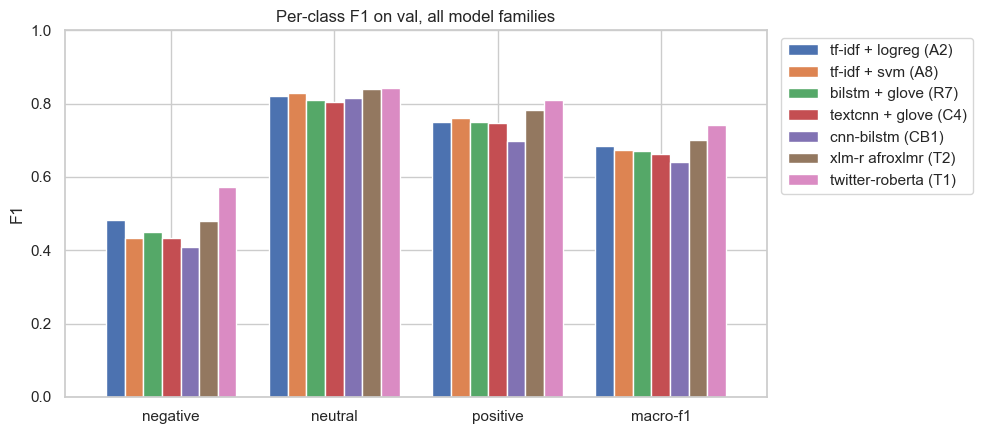

In [21]:
plot_per_class(compare_val, "Per-class F1 on val, all model families", "all_models_per_class_f1")

- All families agree on the class ranking: neutral is easiest (0.80-0.84), positive next, negative much harder (0.40-0.57).
- The bootstrap intervals for the TF-IDF, bilstm and cnn models overlap almost completely (about ±0.03 each). twitter-roberta's interval only just touches the best baseline's, and the paired test in section 6 confirms its lead over the bilstm is real.

## 11. Summary

| question | answer (evidence) |
|---|---|
| random vs pretrained embeddings | pretrained wins, +0.035 over 3 seeds (R1x3 vs R7x3) |
| which pretrained vectors | glove twitter, by a small margin; it's the only one with `<user>`/`<url>` vectors (coverage table) |
| hashtags | splitting `#word` into `<hashtag> word` helps (R7 +0.016, C3 +0.006) |
| rare words | keep the ones glove knows (R8 -0.026 without them) |
| class weights | no gain, unlike the baselines (R6) |
| lstm vs gru | lstm (R9 -0.017) |
| agreement filtering | train on everything (R10-R12 all lower), unlike logreg |
| cnn vs bilstm | tied over seeds (0.660 vs 0.658 on val), cnn trains ~2x faster |
| cnn + bilstm | worse than either (CB1) |
| vs tf-idf | about the same on val, 0.02-0.03 below on test; not significant on val (p = 0.18) |
| vs transformer | twitter-roberta is clearly better (+0.07, p < 0.001) |

The main limit is the data: 7k tweets, a 10% negative class with 23% of it near-random labels, and a val set where seed noise is as big as most single changes. Pretraining on far more text (glove a little, twitter-roberta a lot) is what moves the score, which fits the learning curve.